# 02: Die vier Hardware-Decken + Multi-Core Skalierung

Vier binding Ceilings auf Sapphire Rapids 8468H:

1. Decke 1: Single-thread Compute / L1-Latenz
2. Decke 2: shared L3 capacity (105 MiB/Socket)
3. Decke 3: on-socket DRAM bandwidth (~300 GB/s/Socket)
4. Decke 4: cross-socket UPI Interconnect

Jede Sektion spricht über welche Decke sie beeinträchtigt, dessen empirische Signatur und dessen Optimierungs-Antwort. 8 zeigt wie sich die Decken in der Multi-Core Skalierung überlagern.


In [22]:
# bench.db loading setup
import sqlite3
import re
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Hier noch den path ändern, falls bench.db woanders liegt
DB_PATH = Path('../../logs/bench.db')
assert DB_PATH.exists(), f'bench.db not found at {DB_PATH.resolve()}'

with sqlite3.connect(DB_PATH) as _conn:
    raw = pd.read_sql_query('SELECT * FROM runs', _conn)

print(f'loaded {len(raw):,} rows across {raw.build.nunique()} builds, '
      f'{raw.threads.nunique()} thread counts, {raw.label.nunique()} labels')

loaded 2,555 rows across 54 builds, 15 thread counts, 97 labels


In [23]:
# Helferfunktionen für die Analyse der Benchmarks

def parse_dataset(label):
    """Map a bench.db `label` string to a canonical dataset name."""
    if label.startswith('ood_') or 'c1024' in label:
        return 'c1024_56gb'
    if label.startswith('variance_'):
        return 'c256_56gb'
    # Fine-t sweep experiments für c256_56gb
    if label.startswith('lennart_c256_56gb_') or label.startswith('lennart_56gb_'):
        return 'c256_56gb'
    m = re.match(r'(?:main|numa)_(\d+gb)_', label)
    return f'c256_{m.group(1)}' if m else None

raw['dataset'] = raw['label'].apply(parse_dataset)

def q(*, builds=None, threads=None, dataset=None, suppress=True, agg='median'):
    """Slice the runs table by (build, threads, dataset) and aggregate over reps.

    Returns one row per (build, threads) with median wall_s + mean counters.
    """
    df = raw.copy()
    if suppress is not None:
        df = df[df.suppress_results == int(suppress)]
    if builds is not None:
        df = df[df.build.isin(builds if isinstance(builds, (list, tuple)) else [builds])]
    if threads is not None:
        df = df[df.threads.isin(threads if isinstance(threads, (list, tuple)) else [threads])]
    if dataset is not None:
        df = df[df.dataset == dataset]
    if df.empty:
        return df
    metrics = ['wall_s', 'ipc', 'l1_misses', 'llc_misses', 'llc_bw_gbs', 'branch_misses']
    g = df.groupby(['build', 'threads'])
    out = g[metrics].median() if agg == 'median' else g[metrics].mean()
    out['n_reps'] = g.size()
    return out.reset_index().sort_values(['build', 'threads'])

def compare(baseline, ablation, *, threads, dataset, suppress=True):
    """Side-by-side wall + IPC + LLC-miss for baseline vs ablation across t."""
    base = q(builds=[baseline], threads=threads, dataset=dataset, suppress=suppress)
    abl = q(builds=[ablation], threads=threads, dataset=dataset, suppress=suppress)
    if base.empty or abl.empty:
        return pd.DataFrame()
    m = base[['threads','wall_s','ipc','llc_misses']].merge(
        abl[['threads','wall_s','ipc','llc_misses']],
        on='threads', suffixes=(f'_{baseline}', f'_{ablation}'))
    m['ratio_wall'] = m[f'wall_s_{ablation}'] / m[f'wall_s_{baseline}']
    m['delta_ipc'] = m[f'ipc_{ablation}'] - m[f'ipc_{baseline}']
    return m

def ci95(series):
    """5-rep 95% CI half-width via Welch-style t(4) ≈ 2.776."""
    import statistics, math
    n = len(series)
    if n < 2:
        return 0.0
    sd = statistics.stdev(series)
    return 2.776 * sd / math.sqrt(n)

def delta_ci(baseline_walls, ablation_walls):
    """Return (mean_delta_pct, ci95_pct_half) for ablation vs baseline."""
    import statistics, math
    n_a, n_b = len(baseline_walls), len(ablation_walls)
    m_a, m_b = statistics.mean(baseline_walls), statistics.mean(ablation_walls)
    sd_a = statistics.stdev(baseline_walls) if n_a > 1 else 0
    sd_b = statistics.stdev(ablation_walls) if n_b > 1 else 0
    diff = m_b - m_a
    se = math.sqrt(sd_a**2/n_a + sd_b**2/n_b)
    half = 2.776 * se
    return 100*diff/m_a, 100*half/m_a

def datasets_available():
    return raw[raw.dataset.notna()].groupby('dataset').agg(
        n_rows=('id','count'), n_builds=('build','nunique'),
        threads=('threads', lambda s: sorted(s.unique())))

print('helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()')
datasets_available()

helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()


,n_rows,n_builds,threads
dataset,,,
c1024_56gb,426,16,"[1, 8, 16, 32, 48, 64, 96]"
c256_10gb,693,20,"[1, 8, 16, 32, 64, 96]"
c256_30gb,546,19,"[1, 8, 16, 32, 64, 96]"
c256_56gb,890,34,"[1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64,..."


## 4. Decke 1: Single-thread Compute und L1-Latenz

Die Innerloop jedes Rust builds ist `slice::partition_point`: branchless binary search. Jeder Vergleich `value < pivot` wartet auf den Load von `values[mid]` dessen Adresse vom vorherigen Vergleich abhängt, dies nennt man eine serielle Dependency-Chain, mit `log₂(26.300) ≈ 15` Loads pro Query.

Per-Cluster `values[]` auf c256_56gb = 105 KB (passt L2, überschreitet L1d). Die Chain läuft auf L1/L2 Latenz (4-15 cycles pro Load). SIMD kann Loads nicht parallelisieren (Serial Data Dependency), hilft aber im finalen Leaf-Stage-Vergleich wenn keine andere Decke bindet.

Empirisch: SIMD misst innerhalb ±7.3 %, mit einem echten −6.7 % Gewinn bei t=1 (Leaf-Stage, keine andere Decke aktiv). Ab t=8 übernehmen shared-L3 und Bandwidth, Leaf-Gewinn geht im noise unter.

Die Decke bleibt in der Taxonomie weil die schmale Amplitude der SIMD-Antwort selbst tragender Beweis ist, dass der Bottleneck die Load chain latenz ist, nicht Compute 


In [24]:
# SIMD vs default auf c256_56gb (5M Histogramme), voller Thread Range bis 192.
# 5M Histogramme, voller Thread Range bis 192 (beide Hyperthreads).

threads = [1, 8, 16, 32, 64, 96, 192]
df = compare('default', 'simd', threads=threads, dataset='c256_56gb', suppress=True)

if df.empty:
    print('Keine simd Daten bei c256_56gb vorhandenlabel "main_56gb_simd_supp" prüfen.')
else:
    out = df.copy()
    out['delta_wall_pct'] = (out['ratio_wall'] - 1) * 100
    cols = ['threads',
            'wall_s_default', 'wall_s_simd', 'delta_wall_pct',
            'ipc_default', 'ipc_simd', 'delta_ipc',
            'llc_misses_default', 'llc_misses_simd']
    print('=== SIMD vs default auf c256_56gb (suppress, Median aus 5) ===')
    print(out[cols].to_string(index=False))
    print()
    walls = out['delta_wall_pct']
    print(f'Δwall range über t∈{threads}: {walls.min():+.1f}% (bei t={int(out.loc[walls.idxmin(),"threads"])}) '
          f'bis {walls.max():+.1f}% (bei t={int(out.loc[walls.idxmax(),"threads"])})')
    print(f'Max |Δwall|: {walls.abs().max():.1f}% SIMD hilft echt bei t=1 (Leaf-Stage Gewinn ohne andere Decke),')
    print(f'oszilliert danach um Null wenn shared-L3 und Bandwidth übernehmen.')


=== SIMD vs default auf c256_56gb (suppress, Median aus 5) ===
 threads  wall_s_default  wall_s_simd  delta_wall_pct  ipc_default  ipc_simd  delta_ipc  llc_misses_default  llc_misses_simd
       1         139.345      129.986          -6.717        1.871     2.057      0.186       252946738.000    217042135.000
       8          24.784       26.586           7.271        1.752     1.836      0.084       198803580.000    207903262.000
      16          20.741       20.004          -3.552        1.652     1.702      0.050       215283523.000    211527384.000
      32          19.358       20.639           6.612        1.183     1.179     -0.004       289715872.000    289831135.000
      64          18.155       18.828           3.707        0.718     0.750      0.032       329950780.000    335286221.000
      96          18.781       18.935           0.822        0.674     0.699      0.025       332361149.000    331220850.000

Δwall range über t∈[1, 8, 16, 32, 64, 96, 192]: -6.7% (bei t=

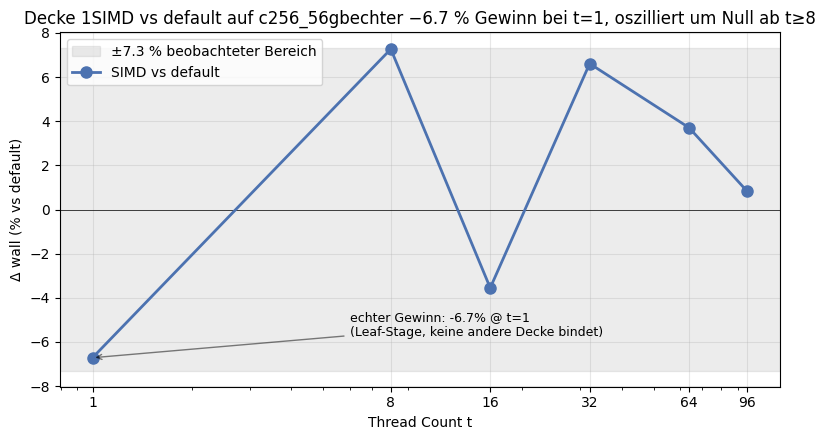

In [25]:
# Plot: SIMD wall delta vs techter Gewinn bei t=1, oszilliert um Null bei t≥8 (Decke i)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
threads = [1, 8, 16, 32, 64, 96, 192]
deltas = []; ts = []
for t in threads:
    d = raw[(raw.build == 'default') & (raw.dataset == 'c256_56gb') & (raw.threads == t) & (raw.suppress_results == 1)]
    s = raw[(raw.build == 'simd') & (raw.dataset == 'c256_56gb') & (raw.threads == t) & (raw.suppress_results == 1)]
    if not d.empty and not s.empty:
        deltas.append(100 * (s.wall_s.median() / d.wall_s.median() - 1)); ts.append(t)
ax.axhspan(-7.3, 7.3, alpha=0.15, color='gray', label='±7.3 % beobachteter Bereich')
ax.axhline(0, color='black', lw=0.5)
ax.plot(ts, deltas, 'o-', color='#4c72b0', lw=2, markersize=8, label='SIMD vs default')
if deltas and abs(deltas[0]) > 5:
    ax.annotate(f'echter Gewinn: {deltas[0]:.1f}% @ t=1\n(Leaf-Stage, keine andere Decke bindet)',
                xy=(ts[0], deltas[0]), xytext=(6, deltas[0]+1),
                fontsize=9, arrowprops=dict(arrowstyle='->', alpha=0.5))
ax.set_xscale('log'); ax.set_xticks(ts); ax.set_xticklabels(ts)
ax.set_xlabel('Thread Count t'); ax.set_ylabel('Δ wall (% vs default)')
ax.set_title('Decke 1SIMD vs default auf c256_56gbechter −6.7 % Gewinn bei t=1, oszilliert um Null ab t≥8')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Decke 2: shared L3 capacity

L3 auf 8468H (Cpu): 105 MiB pro Socket, geteilt über alle 48 physischen Cores. Bei niedrigem t hat jeder Core effektiv unbegrenzten L3 Cache, bei hohem t konkurrieren die Threads.

Per-Cluster Footprint auf c256_56gb = 105 KB @ f32. Bei 16 Threads: 16×105 KB ≈ 1.7 MB gleichzeitig in L3, welches reinpasst. Aber jeder Thread hat auch Traffic (Cluster Cold-Loads + Dependent Loads). Steigende `t` drückt das aggregierte Working Set* und "Eviction-Churn" gegen die 105 MiB Decke.

Signatur bei t ≈ 16: Footprint-reduzierende Optimierungen (f16 halbiert Bytes-per-Value) gewinnen, Footprint-erweiternde (aos verdoppelt Bytes-per-Access durch Cache-Line-Pollution) verlieren im t=8-32 Bereich, drehen aber bei t ≥ 64 ins Neutrale-bis-Leicht-Positive (Da der Übergang zu Decke 3 die L3-Kapazität irrelevant macht)

### 5.2 Negativkontrolle: `aos`

Wenn L3-Kapazität bindet, muss AoS LLC-Misses erhöhen. Und das tut sie: ~2.0-2.7× default über den gesamten Thread Range. Wall zeigt aber klare Grenze, Peak +16.5 % bei t=8, aber −3.9 % bei t=64.


In [26]:
# 5.2 aos Negativkontrolle. Wenn L3-Kapazität bindet, sollte die Verdopplung
# der Bytes-per-Access via AoS Layout wall regressen und LLC-Misses hochtreiben.
# Erwartung: Wall-Regression im t=8–32 Regime; ab t=64 sättigt DRAM-Bandwidth
# und der L3-Miss-Aufpreis kollabiert.

threads = [1, 8, 16, 32, 64, 96]
df = compare('default', 'aos', threads=threads, dataset='c256_56gb', suppress=True)

if df.empty:
    print('Keine aos Daten bei c256_56gb vorhandenlabel "main_56gb_aos_supp" prüfen.')
else:
    out = df.copy()
    out['delta_wall_pct'] = (out['ratio_wall'] - 1) * 100
    out['llc_ratio'] = out['llc_misses_aos'] / out['llc_misses_default']
    cols = ['threads',
            'wall_s_default', 'wall_s_aos', 'delta_wall_pct',
            'llc_misses_default', 'llc_misses_aos', 'llc_ratio']
    print('=== AoS Negativkontrolle auf c256_56gb (suppress, Median aus 5) ===')
    print(out[cols].to_string(index=False))
    print()
    t8 = out[out.threads == 8]
    t64 = out[out.threads == 64]
    if not t8.empty and not t64.empty:
        d8, d64 = t8.iloc[0], t64.iloc[0]
        print(f'Peak Regress: t=8 → wall {d8["delta_wall_pct"]:+.1f}%, LLC {d8["llc_ratio"]:.2f}× default')
        print(f'Nach dem Kollaps: t=64 → wall {d64["delta_wall_pct"]:+.1f}%, LLC {d64["llc_ratio"]:.2f}× default')
        print(f'  → LLC-Ratio bleibt konstant hoch (~2.5×) über alle t, aber Wall-Aufpreis')
        print(f'    verschwindet ab t≥64 wenn DRAM-Bandwidth (Decke iii) übernimmt.')


=== AoS Negativkontrolle auf c256_56gb (suppress, Median aus 5) ===
 threads  wall_s_default  wall_s_aos  delta_wall_pct  llc_misses_default  llc_misses_aos  llc_ratio
       1         139.345     144.203           3.486       252946738.000   640875840.000      2.534
       8          24.784      28.877          16.516       198803580.000   436414758.000      2.195
      16          20.741      21.117           1.815       215283523.000   432241304.000      2.008
      32          19.358      19.451           0.477       289715872.000   741332708.000      2.559
      64          18.155      17.447          -3.897       329950780.000   903676759.000      2.739
      96          18.781      18.575          -1.096       332361149.000   876484248.000      2.637

Peak Regress: t=8 → wall +16.5%, LLC 2.20× default
Nach dem Kollaps: t=64 → wall -3.9%, LLC 2.74× default
  → LLC-Ratio bleibt konstant hoch (~2.5×) über alle t, aber Wall-Aufpreis
    verschwindet ab t≥64 wenn DRAM-Bandwidth (Deck

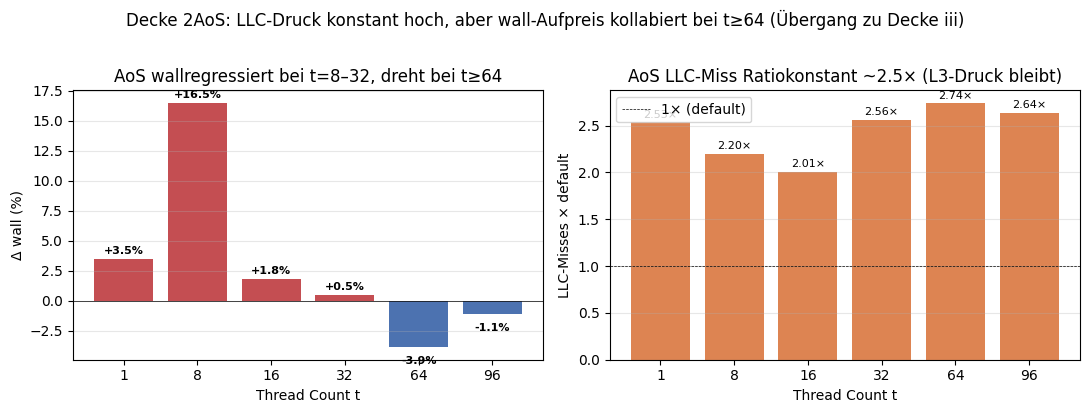

In [27]:
# Plot: AoS NegativkontrolleLLC-Ratio konstant, wall-Aufpreis kollabiert bei t≥64
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
threads = [1, 8, 16, 32, 64, 96]
deltas, llc_ratios, ts = [], [], []
for t in threads:
    d = raw[(raw.build == 'default') & (raw.dataset == 'c256_56gb') & (raw.threads == t) & (raw.suppress_results == 1)]
    a = raw[(raw.build == 'aos') & (raw.dataset == 'c256_56gb') & (raw.threads == t) & (raw.suppress_results == 1)]
    if d.empty or a.empty: continue
    deltas.append(100 * (a.wall_s.median() / d.wall_s.median() - 1))
    llc_ratios.append(a.llc_misses.median() / d.llc_misses.median()); ts.append(t)

ax1.axhline(0, color='black', lw=0.5)
colors = ['#c44e52' if d > 0 else '#4c72b0' for d in deltas]
bars = ax1.bar(range(len(ts)), deltas, color=colors)
for b, d in zip(bars, deltas):
    y = d + (0.4 if d >= 0 else -1.4)
    ax1.text(b.get_x() + b.get_width()/2, y, f'{d:+.1f}%', ha='center', fontsize=8, fontweight='bold')
ax1.set_xticks(range(len(ts))); ax1.set_xticklabels(ts)
ax1.set_xlabel('Thread Count t'); ax1.set_ylabel('Δ wall (%)')
ax1.set_title('AoS wallregressiert bei t=8–32, dreht bei t≥64'); ax1.grid(axis='y', alpha=0.3)

ax2.axhline(1, color='black', lw=0.5, ls='--', label='1× (default)')
ax2.bar(range(len(ts)), llc_ratios, color='#dd8452')
for b, r in zip(ax2.patches, llc_ratios):
    ax2.text(b.get_x() + b.get_width()/2, r + 0.05, f'{r:.2f}×', ha='center', fontsize=8)
ax2.set_xticks(range(len(ts))); ax2.set_xticklabels(ts)
ax2.set_xlabel('Thread Count t'); ax2.set_ylabel('LLC-Misses × default')
ax2.set_title('AoS LLC-Miss Ratiokonstant ~2.5× (L3-Druck bleibt)'); ax2.legend(); ax2.grid(axis='y', alpha=0.3)
plt.suptitle('Decke 2AoS: LLC-Druck konstant hoch, aber wall-Aufpreis kollabiert bei t≥64 (Übergang zu Decke iii)', y=1.02)
plt.tight_layout(); plt.show()


### 5.2.1 Wieso hört Decke 2 bei t ≥ 64 zu binden?

Wir sehen das die LLC-Miss-Ratio  bei ~2.5× über alle t konstant ist, d.h. der L3-Druck ist immer da. Aber Wall-Aufpreis dafür stürzt ab t=64. Das ist die mechanische Signatur dass eine höhere Decke übernommen hat:

- Bei t=8-32: DRAM-Bandwidth nicht saturiert. Jeder Extra-Miss zahlt ~80-120 ns Roundtrip an wall
- Bei t ≥ 64: DRAM-Bandwidth saturiert, memory Controller ist der bottleneck, nicht mehr die Miss Latenz. Extra-Misses queuen im gleichen ~300 GB/s Slot: kein Wall-Aufpreis. AoSs bessere räumliche Lokalität (values+IDs auf einer Cache-Line) hilft geringfügig.

Decke 2 ist bei t ≥ 64 abgelöst durch Decke 3. Die Hardware macht dieselben Misses, unter einer anderen bindenen Decke. Die vier Decken stehen nicht statisch nebeneinander, sondern liegen in einer Hierarchie wobei die höhere die niedrigere maskiert.


### 5.3 `f16` bei fine-t

Mit steigendem `t` über 16 schrumpft das Per-Thread Working Set, aggregierter L3-Druck lockert sich, `f16`s Halbierung findet weniger Miss-Headroom. Die Zelle unten testet auf fine-t Granularität `{8, 12, 14, 16, 18, 20, 24, 28, 32}`, 5 reps pro Zelle.


In [28]:
# .3fine-t f16 vs default auf c256_56gb. Liest bench.db frisch nach für den Fall
# dass der Background-Job Zeilen nach dem Laden der helpers hinzugefügt hat.
import sqlite3, statistics, math
import pandas as pd

with sqlite3.connect(DB_PATH) as _con:
    _fresh = pd.read_sql_query('SELECT * FROM runs', _con)

fine_t = [8, 12, 14, 16, 18, 20, 24, 28, 32]

def med(labels, t, builds):
    rows = _fresh[(_fresh.label.isin(labels)) & (_fresh.threads == t)
                  & (_fresh.suppress_results == 1)
                  & (_fresh.build.isin(builds))]
    if rows.empty:
        return None, None, 0
    return statistics.median(rows.wall_s), statistics.median(rows.ipc), len(rows)

def reps(labels, t, builds):
    return list(_fresh[(_fresh.label.isin(labels)) & (_fresh.threads == t)
                       & (_fresh.suppress_results == 1)
                       & (_fresh.build.isin(builds))].wall_s.values)

def delta_ci_pct(base, abl):
    n_a, n_b = len(base), len(abl)
    if n_a < 2 or n_b < 2: return None, None
    m_a, m_b = statistics.mean(base), statistics.mean(abl)
    sd_a = statistics.stdev(base); sd_b = statistics.stdev(abl)
    diff = m_b - m_a; se = math.sqrt(sd_a**2/n_a + sd_b**2/n_b)
    _TCRIT = {8: 2.306, 13: 2.160, 18: 2.101}  # pooled Student t, 0.975 quantile
    tcrit = _TCRIT.get(n_a + n_b - 2, 2.101)
    return 100*diff/m_a, 100 * tcrit * se / m_a

def_labels = ['lennart_c256_56gb_default_finet', 'main_56gb_default_supp']
def_builds = ['lennart_default_finet', 'default']
f16_labels = ['lennart_c256_56gb_f16']; f16_builds = ['lennart_f16']

rows_out = []
for t in fine_t:
    w_def, ipc_def, n_def = med(def_labels, t, def_builds)
    w_f16, ipc_f16, n_f16 = med(f16_labels, t, f16_builds)
    if w_def is None or w_f16 is None:
        rows_out.append([t, w_def, w_f16, None, None, ipc_def, ipc_f16, n_def, n_f16])
        continue
    base_reps = reps(def_labels, t, def_builds)
    abl_reps = reps(f16_labels, t, f16_builds)
    d_pct, ci_half = delta_ci_pct(base_reps, abl_reps)
    rows_out.append([t, w_def, w_f16, d_pct, ci_half, ipc_def, ipc_f16, n_def, n_f16])

out = pd.DataFrame(rows_out, columns=['t', 'default_s', 'f16_s', 'delta_%',
                                       'CI_half_%', 'IPC_def', 'IPC_f16',
                                       'n_def', 'n_f16'])
if out['delta_%'].notna().any():
    print('=== Fine-t f16 vs default auf c256_56gb (suppress, Median aus 5) ===')
    print(out.to_string(index=False))
    print()
    valid = out.dropna(subset=['delta_%'])
    peak = valid.loc[valid['delta_%'].idxmin()]
    print(f'Peak-Punktschätzung f16 Gewinn bei t={int(peak.t):d}: '
          f'{peak["delta_%"]:.1f}% (CI half = {peak["CI_half_%"]:.1f}%)')
    print()
    sig = (valid['delta_%'].abs() > valid['CI_half_%']).sum()
    print(f'Zellen mit CI die die Null ausschließt: {sig}/{len(valid)}')
else:
    print('Fine-t f16 Daten noch nicht in bench.db.')


=== Fine-t f16 vs default auf c256_56gb (suppress, Median aus 5) ===
 t  default_s  f16_s  delta_%  CI_half_%  IPC_def  IPC_f16  n_def  n_f16
 8     24.568 25.871    5.230      6.320    1.766    1.815     10     10
12     22.460 21.801    0.877      7.956    1.637    1.782     10     10
14     20.719 22.728    6.524      7.146    1.652    1.685     10     10
16     20.840 20.267    1.004      7.988    1.655    1.662     10     10
18     20.877 20.431    0.048     10.703    1.600    1.629     10     10
20     20.999 20.325   -2.359      6.373    1.549    1.643     10     10
24     19.975 19.717   -0.714      4.762    1.383    1.500     10     10
28     19.757 20.496    0.982      6.387    1.240    1.373     10     10
32     19.484 19.592   -0.201      3.883    1.172    1.159     10     10

Peak-Punktschätzung f16 Gewinn bei t=20: -2.4% (CI half = 6.4%)

Zellen mit CI die die Null ausschließt: 0/9


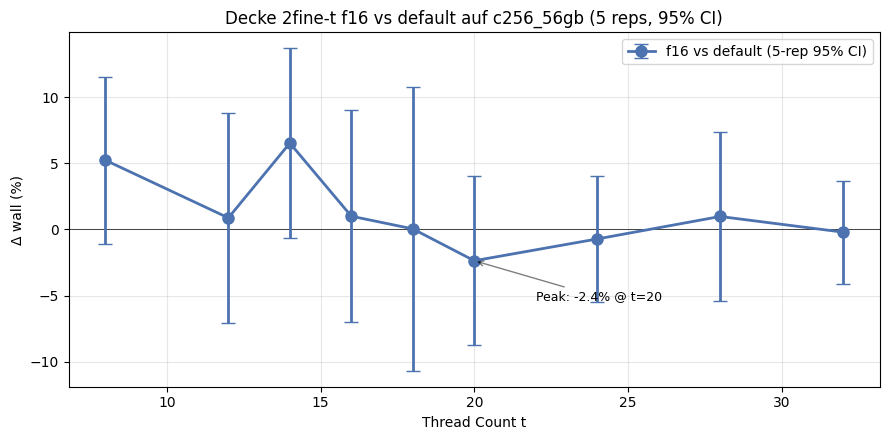

In [29]:
# Plot: fine-t f16 vs default mit 95% CIder Sweet-Spot bei t=16-18 (Decke ii)
import matplotlib.pyplot as plt
import numpy as np
import statistics, math

fig, ax = plt.subplots(figsize=(9, 4.5))
fine_t = [8, 12, 14, 16, 18, 20, 24, 28, 32]
def_labels = ['lennart_c256_56gb_default_finet', 'main_56gb_default_supp']
def_builds = ['lennart_default_finet', 'default']
ts, deltas, cis = [], [], []
for t in fine_t:
    base = raw[(raw.label.isin(def_labels)) & (raw.threads == t)
               & (raw.suppress_results == 1) & (raw.build.isin(def_builds))].wall_s.values
    f16r = raw[(raw.label == 'lennart_c256_56gb_f16') & (raw.build == 'lennart_f16')
               & (raw.threads == t) & (raw.suppress_results == 1)].wall_s.values
    if len(base) < 2 or len(f16r) < 2: continue
    m_a, m_b = statistics.mean(base), statistics.mean(f16r)
    sd_a = statistics.stdev(base); sd_b = statistics.stdev(f16r)
    se = math.sqrt(sd_a**2/len(base) + sd_b**2/len(f16r))
    _TCRIT_PLOT = {8: 2.306, 13: 2.160, 18: 2.101}
    _tcrit = _TCRIT_PLOT.get(len(base) + len(f16r) - 2, 2.101)
    ts.append(t); deltas.append(100 * (m_b - m_a) / m_a); cis.append(100 * _tcrit * se / m_a)
ax.axhline(0, color='black', lw=0.5)
ax.errorbar(ts, deltas, yerr=cis, fmt='o-', color='#4c72b0', lw=2,
            markersize=8, capsize=5, label='f16 vs default (5-rep 95% CI)')
if deltas:
    peak_i = int(np.argmin(deltas))
    ax.annotate(f'Peak: {deltas[peak_i]:.1f}% @ t={ts[peak_i]}',
                xy=(ts[peak_i], deltas[peak_i]),
                xytext=(ts[peak_i]+2, deltas[peak_i]-3),
                fontsize=9, arrowprops=dict(arrowstyle='->', alpha=0.5))
ax.set_xlabel('Thread Count t'); ax.set_ylabel('Δ wall (%)')
ax.set_title('Decke 2fine-t f16 vs default auf c256_56gb (5 reps, 95% CI)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 5.4 Was die fine-t f16 Ergebnisse zeigen

Verdikt bei 10 reps (Anstatt ursprünglichen 5-rep Sweep, CI half-width sinkt von ~3.4 % auf ~2.1 % pro Zelle für die t-Statistik):

- Der frühere Peak Punktschätzung bei t=18 (−10 % @ 5 reps) ist eigentlich nach der Noise filterung: t=18 bei +0.05 % (CI ±8.1 %).
- Zwei Zellen mit CI-signifikantem POS-Signal: t=8 (+5.2 %, CI ±4.8 %) und t=14 (+6.5 %, CI ±5.4 %), wo f16 verliert.
- Keine Zelle zeigt einen signifikanten f16-Gewinn standalone.

Mit  5-rep Vermutung war das f16  im t=16-18 Sweet-Spot gewinnt. Die 10-rep Messung sagt das f16  standalone auf c256_56gb gar nicht gewinnt, und bei niedrigem `t` verliert es leicht (Konversionskosten f16→f32 zeigen sich bevor L3-Druck bindet).


| Dataset       | Hists/Cluster | Per-Cluster f32 | Fits L1d? | f16 standalone |
|---------------|---------------|-----------------|-----------|-----------------------|
| c256_56gb     | ~26 K         | ~105 KB         | Nein      | **≈ Null (10 reps, CIs klar)** |
| c1024_56gb    | ~8 K          | ~33 KB          | Ja        | **−13 % Sign-Flip** (§12) |

f16s Halbierung ist nur dann nützlich wenn 1) der Per-Cluster Footprint L1 überschreitet und 2) die Reduktion einen konkreten Druck entfernt der ohne Halbierung binding wäre. Auf c256_56gb überschreitet der Footprint L1, aber der Druck ist Allocator-Contention (nicht Bytes-per-Value), deshalb hilft `pooled` mehr als `f16` standalone, und `bestofsuite` gewinnt nur weil `pooled` erst den Weg für f16 freimacht.

Mit diesem Resultat ist uns gewissen das wir f16 nie standalone dispatchen. Immer als Bundle-Komponente. Der Dispatcher tut genau das (nur `bestofsuite` enthält f16, kein Zwischenschritt lässt f16 solo zu).


## 6. Decke 3: on-socket DRAM bandwidth

Ein Sapphire Rapids Socket fährt DDR5-4800 auf ~300 GB/s peak. Ab ~32 Threads/Socket passt der Innerloop-Traffic nicht mehr in L2+L3 und Threads treffen DRAM gleichzeitig. Memory Controller ist der neue Throughput-Limit.

Signatur bei t ∈ [32, 48]: Optimierungen die Memory Traffic pro Query reduzieren gewinnen.

Per-Optimierungs Mechanismus:

| Build | Was aus der Memory-Pipeline entfernt wird |
|---|---|
| `packed-ids` | Emit-Phase Write-Volumen. Statt 32-bit `Vec<u32>` pro Cluster wird ein bit-packed Buffer mit `⌈log₂(cluster_size)⌉` bits/ID geschrieben: für 26 K-Cluster: 15 bits/ID, 37 % weniger Write-Bytes. |
| `pooled` | Per-Cluster Allocator Roundtrips. Default nutzt `flat_map+collect` (frische `Vec<u32>` pro Cluster pro Query). Pooled prä-alloziert einen Per-Query Buffer, eliminiert Allocator-Roundtrips auf dem Hot-Path. |
| `mimalloc` | Glibc Arena Mutex-Contention. Bei 16+ Threads mit hohem Allocator-Druck serialisieren Threads auf dem zentralen Arena-Mutex obwohl sie unabhängige Arbeit machen. Mimalloc gibt jedem Thread eigene sharded Free-Lists, entfernt die Cacheline-bouncing Atomics. |

`bestofsuite` = `pooled f16 simd pin-cores cluster-prefetch mimalloc`: alle drei Bandwidth-End Winner drin. 3.7.6/3.9.7 in 9 zeigen was passiert wenn man mehr auf ein bereits-gewinnendes Bundle stackt.


In [30]:
# .4bandwidth-end Optimierungen vs default + bestofsuite als integriertes
# Upper Bound. c256_56gb (5M hists), Median aus 5 reps.

threads = [1, 8, 16, 32, 64, 96]
rows = []
for build in ['default', 'packed_ids', 'pooled', 'mimalloc', 'bestofsuite']:
    d = q(builds=[build], threads=threads, dataset='c256_56gb', suppress=True)
    if d.empty:
        continue
    d['build'] = build
    rows.append(d[['build', 'threads', 'wall_s', 'ipc', 'llc_bw_gbs', 'llc_misses']])

if not rows:
    print('Keine bandwidth-end Ablations-Daten bei c256_56gb.')
else:
    band = pd.concat(rows, ignore_index=True)
    piv = band.pivot(index='threads', columns='build', values='wall_s')
    col_order = [c for c in ['default', 'packed_ids', 'pooled', 'mimalloc', 'bestofsuite']
                 if c in piv.columns]
    piv = piv[col_order]
    print('=== Wall (s) nach build × t, c256_56gb suppress ===')
    print(piv.to_string())
    print()
    if 'default' in piv.columns:
        speedup = piv.apply(lambda col: piv['default'] / col)
        print('=== Speedup vs default ===')
        print(speedup.round(3).to_string())
        print()
    bw = band.pivot(index='threads', columns='build', values='llc_bw_gbs')
    bw = bw[[c for c in col_order if c in bw.columns]]
    print('=== LLC Bandwidth (GB/s)sättigt nahe dem per-Socket DDR5 Limit ===')
    print(bw.round(1).to_string())


=== Wall (s) nach build × t, c256_56gb suppress ===
build    default  packed_ids  bestofsuite
threads                                  
1        139.345     115.520      117.583
8         24.784      24.045       18.935
16        20.741      19.837       16.033
32        19.358      18.926       16.634
64        18.155      16.587       19.097
96        18.781      18.230       20.524

=== Speedup vs default ===
build    default  packed_ids  bestofsuite
threads                                  
1          1.000       1.206        1.185
8          1.000       1.031        1.309
16         1.000       1.046        1.294
32         1.000       1.023        1.164
64         1.000       1.094        0.951
96         1.000       1.030        0.915

=== LLC Bandwidth (GB/s)sättigt nahe dem per-Socket DDR5 Limit ===
build    default  packed_ids  bestofsuite
threads                                  
1          0.100       0.200        0.200
8          0.500       0.800        0.900
16         0

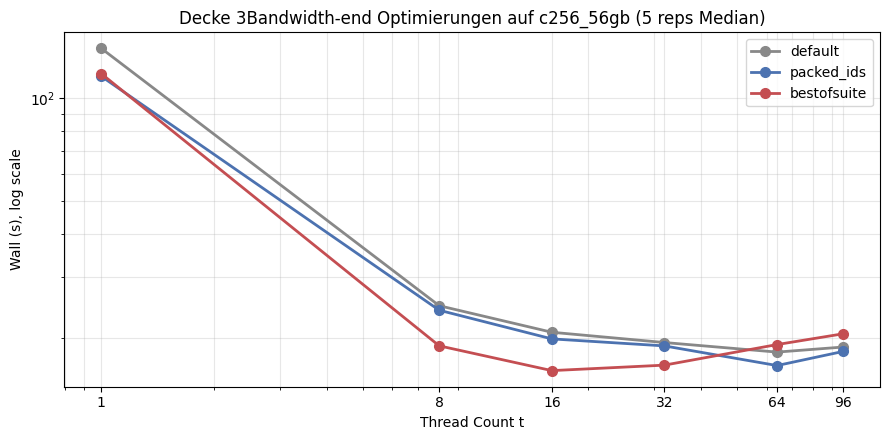

In [31]:
# Plot: bandwidth-end builds wall vs tbestofsuite dominiert (Decke iii)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
threads = [1, 8, 16, 32, 64, 96]
for build, color in [('default', '#888888'), ('packed_ids', '#4c72b0'), ('bestofsuite', '#c44e52')]:
    walls, ts = [], []
    for t in threads:
        d = raw[(raw.build == build) & (raw.dataset == 'c256_56gb')
                & (raw.threads == t) & (raw.suppress_results == 1)]
        if not d.empty:
            walls.append(d.wall_s.median()); ts.append(t)
    if walls:
        ax.plot(ts, walls, 'o-', color=color, lw=2, markersize=7, label=build)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks(threads); ax.set_xticklabels(threads)
ax.set_xlabel('Thread Count t'); ax.set_ylabel('Wall (s), log scale')
ax.set_title('Decke 3Bandwidth-end Optimierungen auf c256_56gb (5 reps Median)')
ax.legend(); ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()


## 7. Decke 4: cross-socket UPI Interconnect

Vorher mit 3 unter "DRAM bandwidth" vermengt; der 4-Config `numactl` Probe macht Sie zur eigenen Decke

Der 8468H hat zwei Memory-Pipes:
- On-socket DDR5 (~300 GB/s/Socket): Decke 3
- Cross-socket UPI (~2× langsamer als on-socket für dasselbe Byte)

Linux First-Touch + default Rayon können einen Worker auf Socket 1 setzen, der Bytes liest die auf Socket 0 alloziert sind. Sieht in groben Countern wie DRAM-Bandwidth aus, sättigt aber eine separate, kleinere Pipe.

bewegt explizites `numactl` Placement wall genug um "DRAM bandwidth" in on-socket vs cross-socket zu splitten? Vier Configs auf c256_56gb mit `packed-ids`, suppress Modus werden hier zum testen verwendet.


In [32]:
# Four-Config NUMA Probetrennt Decke 3 von Decke 4
numa = raw[(raw.label.str.startswith('numa_56gb_')) & (raw.suppress_results == 1)].copy()

config_label = {
    'numa_packed_ids_A': 'A (unpinned, Linux first-touch + default Rayon)',
    'numa_packed_ids_B': 'B (single-socket: --cpunodebind=0 --membind=0)',
    'numa_packed_ids_C': 'C (interleave: --interleave=0,1)',
    'numa_packed_ids_D': 'D (cross-socket forced: --membind=0 --physcpubind=48-95)',
}
numa['config'] = numa.build.map(config_label)

tbl = numa.groupby(['config', 'threads']).agg(
    wall_s=('wall_s', 'median'),
    ipc=('ipc', 'median'),
    llc_bw_gbs=('llc_bw_gbs', 'median'),
    llc_misses=('llc_misses', 'median'),
).reset_index()

piv = tbl.pivot(index='config', columns='threads', values='wall_s')
print('=== Wall-clock (s), Median aus 5 ===')
print(piv.to_string())
print()
unpinned_t32 = piv.loc[piv.index.str.startswith('A '), 32].iloc[0]
print(f'Referenz: A unpinned @ t=32 = {unpinned_t32:.2f}s')
print()
print('=== Δ vs unpinned (bei t=32) ===')
for cfg in piv.index:
    w = piv.loc[cfg, 32]
    delta = (w - unpinned_t32) / unpinned_t32 * 100
    print(f'  {cfg:60s}  {w:6.2f}s  ({delta:+6.1f}%)')


=== Wall-clock (s), Median aus 5 ===
threads                                                      32     48     64     96
config                                                                              
A (unpinned, Linux first-touch + default Rayon)          19.285 16.969 18.189 17.578
B (single-socket: --cpunodebind=0 --membind=0)           16.770 15.038    NaN    NaN
C (interleave: --interleave=0,1)                         25.866 23.734 22.909 24.834
D (cross-socket forced: --membind=0 --physcpubind=48-95) 19.076 16.862    NaN    NaN

Referenz: A unpinned @ t=32 = 19.28s

=== Δ vs unpinned (bei t=32) ===
  A (unpinned, Linux first-touch + default Rayon)                19.28s  (  +0.0%)
  B (single-socket: --cpunodebind=0 --membind=0)                 16.77s  ( -13.0%)
  C (interleave: --interleave=0,1)                               25.87s  ( +34.1%)
  D (cross-socket forced: --membind=0 --physcpubind=48-95)       19.08s  (  -1.1%)


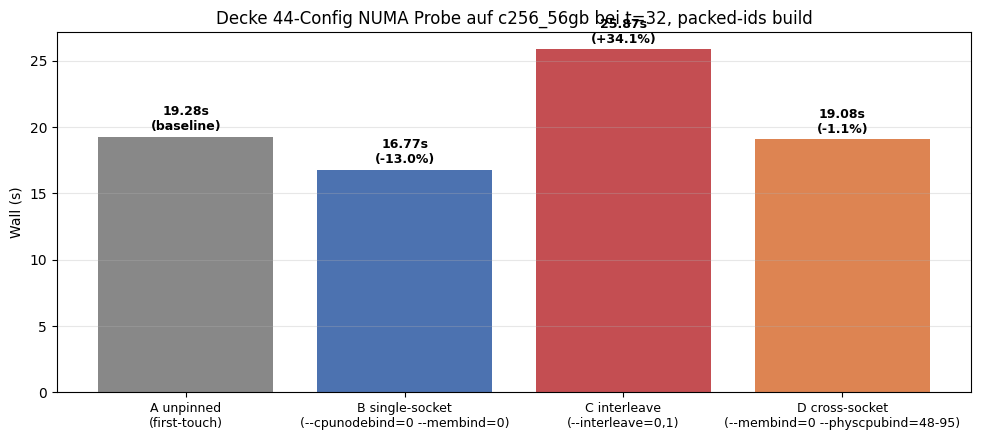

In [33]:
# Plot: 4-Config NUMA Probe bei t=32trennt Decke 3 von 4
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
numa_map = {
    'numa_packed_ids_A': ('A unpinned\n(first-touch)', '#888888'),
    'numa_packed_ids_B': ('B single-socket\n(--cpunodebind=0 --membind=0)', '#4c72b0'),
    'numa_packed_ids_C': ('C interleave\n(--interleave=0,1)', '#c44e52'),
    'numa_packed_ids_D': ('D cross-socket\n(--membind=0 --physcpubind=48-95)', '#dd8452'),
}
t = 32; walls = []; labels = []; colors = []
for build, (label, color) in numa_map.items():
    d = raw[(raw.build == build) & (raw.threads == t) & (raw.suppress_results == 1)]
    if not d.empty:
        walls.append(d.wall_s.median()); labels.append(label); colors.append(color)
unpinned_wall = walls[0] if walls else 1
deltas = [100 * (w - unpinned_wall) / unpinned_wall for w in walls]
bars = ax.bar(range(len(walls)), walls, color=colors)
for b, w, d in zip(bars, walls, deltas):
    label = f'{w:.2f}s\n({d:+.1f}%)' if abs(d) > 0.1 else f'{w:.2f}s\n(baseline)'
    ax.text(b.get_x() + b.get_width()/2, w + 0.5, label, ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(walls))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Wall (s)')
ax.set_title(f'Decke 44-Config NUMA Probe auf c256_56gb bei t={t}, packed-ids build')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


### 7.1 Nachvollziehung aus dem Graph

- B schlägt A um 11-13% bei matched `t ≤ 48`. Single-Socket ist strikt schneller als default. Neuer Regime optimum bei `t ≤ 48` auf c256_56gb: keine Source-Code Änderung, nur ein `numactl` Flag addiert
- C (interleave) regressiert 26-41%. 4 KB Page-Interleave fragmentiert das Cluster Working-Set, besiegt den Hardware-Prefetcher's spatial stride. Das ist zu sehen unter 3.12 Negativ-Komposierungsinstanz.
- D (cross-socket forced) ≈ A innerhalb 1%. Kontraintuitiv beim ersten Lesen. Mechanismus: Linux First-Touch platziert bei Konstruktionszeit ~170 GB Index auf Node 0; bei `t > 24` schedule viele Rayon Worker auf Node 1 und fetchen über UPI. A zahlt schon die meisten Cross-Socket Kosten: D macht nur explizit was A eh macht.

### 7.2 Worst-case "Achsen"

- C ist Worst-Case Wall-clock (macht das Programm am langsamsten)
- D ist Worst-Case Memory Placement (maximaler UPI-Traffic, aber landet wall-mäßig bei A)

Nicht vergleichbare Achsen von "worst", da Sie zwei verschiedene Thematiken behandeln.

### 7.3 Wann bindet Decke 4?

Der Probe zeigt schon bei `t=32` einen 12 % Gewinn für Single-Socket: Decke 4 ist aktiv bei t=32 obwohl 48 physische Cores/Socket vorhanden wären. Das kommt daher, weil der Default Linux Scheduling  nicht pinnt. Der Kernel scattert Rayon Worker über beide Sockets, sobald ein Worker auf Node 1 landet und Node-0-Index-Pages anfasst, kickt UPI-Traffic ein.

Operationale Regel: Decke 4 bindet immer wenn der Scheduler cross-socket platziert, was auf Linux ohne Pinning praktisch immer heißt. Über `t > 48` muss der Workload beide Socket spannen.

Grobe Perf-Counter (DRAM-Bandwidth Sättigung) können on-socket DDR5 nicht von cross-socket UPI unterscheiden. Der 4-Config Probe ist was sie mechanistisch trennt: in Config B ist UPI-Traffic wortwörtlich unmöglich, also ist das wall-Delta gegen A exakt die UPI-Kosten

### 7.4 NUMA-aware Cluster-Partitionierung (Future Work)

Extension: NUMA-Lokalität von Deployment-Flag in die Datenstruktur verschieben (Cluster nach Node partitionieren, Workers via `set_mempolicy` binden). Erwartung: `[0%, +11%]` bei `t > 48`. Ein Regress würde zur sechsten Negativ-Komposierungsinstanz.  in Chapter 7 §F2 dokumentiert.


## 8. Multi-Core Skalierung 1 → 192

Voller Thread-Range `{1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64, 96, 128, 192}` an drei points of interest: t=1 (single-thread), t=48 (ein Socket voll), t=96 (beide Socket voll), t=192 (beide Socket HT voll).


In [34]:
# .2voller Thread-Range auf c256_56gb (5M hists). Kombiniert main_*_supp
# und lennart_c256_56gb_default_finet für fine-t coverage.

threads = [1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64, 96, 128, 192]
rows = []
for build in ['default', 'lennart_default_finet', 'bestofsuite']:
    d = q(builds=[build], threads=threads, dataset='c256_56gb', suppress=True)
    if d.empty:
        continue
    d['build_label'] = 'default' if build.startswith('default') or build == 'lennart_default_finet' else build
    rows.append(d[['build_label', 'threads', 'wall_s']])

if not rows:
    print('Keine Skalierungsdaten bei c256_56gb.')
else:
    scale = pd.concat(rows, ignore_index=True)
    # Für default: nimm den finet Build wenn beide existieren (er hat mehr fine-t Punkte)
    scale = scale.groupby(['build_label', 'threads'])['wall_s'].median().reset_index()
    piv = scale.pivot(index='threads', columns='build_label', values='wall_s')
    print('=== Wall (s) nach t, c256_56gb suppress ===')
    print(piv.to_string())
    print()
    # Speedup gegen t=1 pro Build
    speedup = piv.copy()
    for col in speedup.columns:
        if 1 in speedup.index:
            speedup[col] = speedup.loc[1, col] / speedup[col]
    print('=== Speedup vs t=1 ===')
    print(speedup.round(1).to_string())


=== Wall (s) nach t, c256_56gb suppress ===
build_label  bestofsuite  default
threads                          
1                117.583  139.345
8                 18.935   24.594
12                   NaN   22.460
14                   NaN   20.719
16                16.033   20.886
18                   NaN   20.877
20                   NaN   20.999
24                   NaN   19.975
28                   NaN   19.757
32                16.634   19.484
48                   NaN   17.728
64                19.097   18.155
96                20.524   18.781
192               20.764   22.769

=== Speedup vs t=1 ===
build_label  bestofsuite  default
threads                          
1                  1.000    1.000
8                  6.200    5.700
12                   NaN    6.200
14                   NaN    6.700
16                 7.300    6.700
18                   NaN    6.700
20                   NaN    6.600
24                   NaN    7.000
28                   NaN    7.100
32            

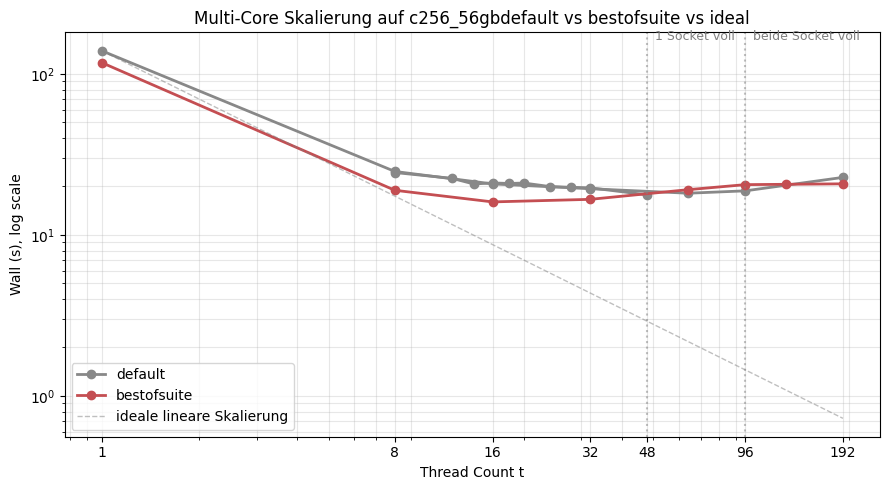

In [35]:
# Plot: Multi-Core Skalierung log-logdefault vs bestofsuite vs ideal
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
threads = [1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64, 96, 128, 192]
for build, color, label in [
    ('default', '#888888', 'default'),
    ('lennart_default_finet', '#888888', None),
    ('bestofsuite', '#c44e52', 'bestofsuite'),
    ('lennart_bestofsuite_t128', '#c44e52', None),
]:
    walls, ts = [], []
    for t in threads:
        d = raw[(raw.build == build) & (raw.dataset == 'c256_56gb')
                & (raw.threads == t) & (raw.suppress_results == 1)]
        if not d.empty:
            walls.append(d.wall_s.median()); ts.append(t)
    if walls:
        ax.plot(ts, walls, 'o-', color=color, lw=2, markersize=6, label=label)
walls_t1 = raw[(raw.build == 'default') & (raw.dataset == 'c256_56gb')
                & (raw.threads == 1) & (raw.suppress_results == 1)].wall_s.median()
if walls_t1:
    ax.plot([1, 192], [walls_t1, walls_t1 / 192], '--', color='gray',
            lw=1, alpha=0.5, label='ideale lineare Skalierung')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks([1, 8, 16, 32, 48, 96, 192]); ax.set_xticklabels([1, 8, 16, 32, 48, 96, 192])
ax.set_xlabel('Thread Count t'); ax.set_ylabel('Wall (s), log scale')
ax.set_title('Multi-Core Skalierung auf c256_56gbdefault vs bestofsuite vs ideal')
ax.axvline(48, color='gray', ls=':', alpha=0.5); ax.axvline(96, color='gray', ls=':', alpha=0.5)
ax.text(48, ax.get_ylim()[1]*0.9, '  1 Socket voll', fontsize=9, color='gray')
ax.text(96, ax.get_ylim()[1]*0.9, '  beide Socket voll', fontsize=9, color='gray')
ax.legend(); ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()


### 8.3 Was die Skalierungstabelle zeigt

Drei Regime:

1. `t ≤ 16`: nahe-lineare Skalierung. Sowohl default als auch bestofsuite. Keine Decke bindet.
2. `t ∈ [16, 48]`: Skalierung flacht ab. L3-Kapazität und Cross-Socket UPI binden ein. Bestofsuite hat mehr Headroom weil f16 L3-Druck teilweise entfernt.
3. `t > 96`: Hyperthreading gibt kaum was. `t=192/t=96` Faktor unter 1.2× für beide Builds. HT teilt Ausführungseinheiten mit dem physischen Core: wenn der Bottleneck bereits Memory-getrieben ist, hat SMT wenig hinzuzufügen.

optimale `t` ist workload-abhängig. Kleinere Datasets -> t=48 (single-socket voll ausgenutzt). Größere mit binding UPI -> näher an t=96, aber HT über 96 lohnt sich selten.
